In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import numpy as np
import scipy.stats
from scipy.special import logit, expit
import matplotlib.pyplot as plt

import sys
sys.path.append('../../python/example/berry')
import util

sigma2_n = 90
n_arms = 2
mu_sig_sq = 100.0
mu_0 = -1.34
logit_p1 = logit(0.3)
n = np.full(2, 10)
y = np.array([1, 3])
n.shape, y.shape

((2,), (2,))

In [32]:
sigma2_n = sigma2_n
sigma2_rule = util.log_gauss_rule(sigma2_n, 1e-6, 1e3)
arms = np.arange(n_arms)
cov = np.full((sigma2_n, n_arms, n_arms), mu_sig_sq)
cov[:, arms, arms] += sigma2_rule.pts[:, None]
neg_precQ = -np.linalg.inv(cov)
logprecQdet = 0.5 * np.log(np.linalg.det(-neg_precQ))
log_prior = scipy.stats.invgamma.logpdf(
    sigma2_rule.pts, 0.0005, scale=0.000005
)

In [33]:
def calc_log_joint(theta, sig_idx):
    theta_m0 = theta - mu_0
    theta_adj = theta + logit_p1
    exp_theta_adj = np.exp(theta_adj)
    out = (
        0.5 * np.einsum("...i,...ij,...j", theta_m0, neg_precQ[sig_idx], theta_m0)
        + np.sum(
            theta_adj * y[None] - n[None] * np.log(exp_theta_adj + 1),
            axis=-1,
        )
    )
    out -= np.max(out)
    return out

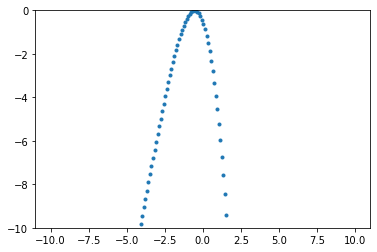

In [34]:
ts = np.linspace(-10, 10, 200)
theta2d = np.meshgrid(ts, ts, indexing = 'ij')
theta = np.stack([ti.ravel() for ti in theta2d], axis=-1)
theta1d = np.stack((theta2d[0][:,0], theta2d[0][:,0]),axis=-1)
theta1d[:,1] = theta1d[:,0]
theta = theta1d
sig_idx = 0
logjoint = calc_log_joint(theta, sig_idx)
logjoint -= logjoint.max()
levels = np.linspace(-10, 0, 21)
plt.plot(theta1d[:,0], logjoint, '.')
plt.ylim([-10, 0])
plt.show()

In [35]:
import berry
import inla
model = berry.Berry(sigma2_n=sigma2_n, n_arms=2)
max_sigma2 = 2.0
w_quad = 6.0
n_quad = 11
data = np.stack(([[1,3]],[[10,10]]), axis=-1)
x0_info = inla.optimize_x0(model, data[:, None, :], sigma2_rule.pts[None, :, None])
# Note: in INLA notation, x is used to refer to the Berry "theta"
thetacenters = x0_info["x"]
thetastd = np.minimum(
    np.sqrt(sigma2_rule.pts), np.full_like(sigma2_rule.pts, max_sigma2)
)
thetamins = thetacenters - w_quad * thetastd[None, :, None]
thetamaxs = thetacenters + w_quad * thetastd[None, :, None]
# points, weights = np.polynomial.legendre.leggauss(n)
# thetapts = np.transpose(
#     thetamins[None, :, :, :]
#     + (thetamaxs[None, :, :, :] - thetamins[None, :, :, :])
#     * (points[:, None, None, None] * 0.5 + 0.5),
#     (1, 2, 3, 0),
# )
# thetawts = (
#     weights[None, None, None, :]
#     * (thetamaxs[:, :, :, None] - thetamins[:, :, :, None])
#     * 0.5
# )

In [36]:
def find_integration_domain(sig_idx):
    ws = np.linspace(0, 15, 21)
    tol = 1e-10
    log_tol = np.log(tol)
    domain = np.empty((n_arms, 2))
    for dim in range(n_arms):
        for sign_idx, sign in enumerate([-1, 1]):
            shift = np.empty((ws.shape[0], thetacenters.shape[0], thetacenters.shape[2]))
            shift[:] = thetacenters[:,sig_idx,:]
            shift[..., dim] += sign * ws[:, None] * thetastd[sig_idx]
            shift_log_joint = calc_log_joint(shift, sig_idx)
            above_tol = shift_log_joint[:,0] > log_tol
            if np.all(above_tol):
                raise ValueError("Maximum width insufficient for covering the relevant integration domain.")
            elif np.any(above_tol):
                w_idx = np.argmin(above_tol)
            else:
                w_idx = 1
            use_w = ws[w_idx] * thetastd[sig_idx]
            domain[dim, sign_idx] = sign * use_w
    return domain
            # print(dim, sign, use_w)

In [37]:
n_quad = 8
w_quad = 10
points, weights = np.polynomial.legendre.leggauss(n_quad)
etapts = w_quad * points
etawts = w_quad * weights
grid_eta = np.stack(np.meshgrid(*[etapts for k in range(n_arms)], indexing="ij"), axis=-1)
grid_eta_wts = np.prod(np.stack(np.meshgrid(*[etawts for k in range(n_arms)], indexing="ij"), axis=-1), axis=-1)

phat = (y/n)[None, :]
sample_I = n * phat * (1 - phat)

sigma_precision = np.empty((sample_I.shape[0], *neg_precQ.shape))
sigma_precision[:] = neg_precQ[None, ...]
sigma_precision[..., arms, arms] += sample_I[:, None, ...]
sigma_posterior = np.linalg.inv(sigma_precision)
w, v = np.linalg.eigh(sigma_posterior)

x0_info = inla.optimize_x0(model, data[:, None, :], sigma2_rule.pts[None, :, None])
mode = x0_info['x']

broadcast_shape = list(mode.shape)
for i in range(n_arms):
    broadcast_shape.insert(2, 1)
grid_theta = np.einsum('klij,...i,kli->kl...j', v, grid_eta, w) + mode.reshape(broadcast_shape)

# We need to multiply by the absolute value of the determinant of the
# transformation. Because we have already computed a eigendecomposition, the
# determinant of matrix is just product of eigenvalues.
det_jacobian = np.abs(w.prod(axis=-1))
grid_theta_wts = np.einsum('kl,...->kl...', det_jacobian, grid_eta_wts)

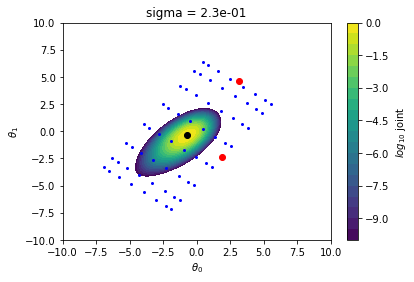

In [38]:
ts = np.linspace(-10, 10, 200)
theta2d = np.meshgrid(ts, ts, indexing = 'ij')
theta = np.stack([ti.ravel() for ti in theta2d], axis=-1)
for sig_idx in [50]:#range(0, sigma2_n, 10):
    domain = find_integration_domain(sig_idx)
    theta_m0 = theta - mu_0
    theta_adj = theta + logit_p1
    exp_theta_adj = np.exp(theta_adj)
    logjoint = calc_log_joint(theta, sig_idx)
    levels = np.linspace(-10, 0, 21)
    plt.contourf(theta2d[0], theta2d[1], logjoint.reshape(theta2d[0].shape), levels=levels)
    plt.plot(*mode[0,sig_idx], 'ko')

    plt.plot(grid_theta[0, sig_idx, :,:,0].ravel(), grid_theta[0, sig_idx, :,:,1].ravel(), 'bo', markersize=2)

    plt.plot(*(mode[0,sig_idx] + w[0,sig_idx,0] * 10 * v[0,sig_idx,0]), 'ro')
    plt.plot(*(mode[0,sig_idx] + w[0,sig_idx,1] * 10 * v[0,sig_idx,1]), 'ro')
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$')

    plt.title(f'sigma = {sigma2_rule.pts[sig_idx]:.1e}')
    cbar = plt.colorbar()
    cbar.set_label('$log_{10}$ joint')
    plt.show()

In [46]:
import quadrature
import fast_inla
y = np.array([[4, 8]])
n = np.array([[35, 35]])
fi = fast_inla.FastINLA(2, sigma2_n=sigma2_n)
pts, wts = quadrature.build_centered_quad_rules(fi, y, n)

In [48]:
pts.shape, wts.shape

((1, 11, 11, 90, 3), (1, 11, 11, 90))

In [49]:
pr = pts[...,:2].reshape((-1, fi.sigma2_n, fi.n_arms))
pr.shape

(121, 90, 2)

In [26]:
fi.numpy_inference(y, n)

TypeError: FastINLA.log_joint() missing 2 required positional arguments: 'n' and 'theta'

In [50]:
log_joint = fi.log_joint(y, n, pr)
log_joint * wts

array([[-29.58899323, -29.53525234, -29.44162994, ..., -63.12617427,
        -63.17973023, -63.20954564],
       [-29.10002685, -29.04628598, -28.95266361, ..., -61.66162786,
        -61.7152136 , -61.74504526],
       [-28.34262259, -28.28888174, -28.19525942, ..., -59.5898752 ,
        -59.64350311, -59.67335779],
       ...,
       [-28.90114969, -28.84740884, -28.75378649, ..., -56.98615602,
        -57.03983033, -57.06971032],
       [-30.09458672, -30.04084584, -29.94722343, ..., -57.75347071,
        -57.80713062, -57.83700273],
       [-30.91651392, -30.86277301, -30.76915057, ..., -58.23133049,
        -58.28498115, -58.3148482 ]])

In [34]:
pts.shape, wts.shape

((1, 15, 11, 11, 3), (1, 15, 11, 11))

In [ ]:
pts.reshape()

In [28]:
broadcast_shape = 
for i in range(fi.n_arms):
    broadcast_shape.insert(2, 1)
pts = np.empty((*wts.shape, 3))
pts[...,:2] = pts
np.concatenate((pts, fi.sigma2_rule.pts[None, :, None, None, None]), axis=-1)

ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 2, the array at index 0 has size 11 and the array at index 1 has size 1